In [1]:
# ── Shell 1: Imports & Dataset Paths ──────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, top_k_accuracy_score)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import lightgbm as lgb
import joblib

# ── ✏️  PASTE YOUR KAGGLE DATASET PATHS HERE ──────────────────────────────────
TRAIN_PATH = "/kaggle/input/datasets/kedarkothari/disease-prediction/Disease Prediction/training.csv.csv"   # <-- change this
TEST_PATH  = "/kaggle/input/datasets/kedarkothari/disease-prediction/Disease Prediction/testing.csv.csv"    # <-- change this
# ──────────────────────────────────────────────────────────────────────────────

print("✅ Libraries loaded")

✅ Libraries loaded


In [2]:
# ── Shell 2: Load & Clean Data ────────────────────────────────────────────────
train = pd.read_csv(TRAIN_PATH)
test  = pd.read_csv(TEST_PATH)

# Drop junk column in test (Unnamed: 133)
test.drop(columns=[c for c in test.columns if 'Unnamed' in c], inplace=True)

# Strip whitespace from disease labels
train['prognosis'] = train['prognosis'].str.strip()
test['prognosis']  = test['prognosis'].str.strip()

print(f"Train shape : {train.shape}")
print(f"Test  shape : {test.shape}")
print(f"\nUnique diseases : {train['prognosis'].nunique()}")
print(f"Missing values  : train={train.isnull().sum().sum()} | test={test.isnull().sum().sum()}")
print(f"\nClass distribution (train):\n{train['prognosis'].value_counts()}")

Train shape : (12320, 133)
Test  shape : (4920, 133)

Unique diseases : 41
Missing values  : train=0 | test=0

Class distribution (train):
prognosis
Heart attack                               349
Chronic cholestasis                        349
Bronchial Asthma                           348
Hyperthyroidism                            347
Hepatitis C                                346
Migraine                                   345
Hepatitis E                                341
Drug Reaction                              337
Allergy                                    335
Hepatitis B                                334
Varicose veins                             329
hepatitis A                                328
Malaria                                    324
Hypoglycemia                               320
Impetigo                                   320
Urinary tract infection                    313
Acne                                       308
Fungal infection                           301
Hypot

In [3]:
# ── Shell 3: Feature Engineering ──────────────────────────────────────────────
def add_features(df):
    df = df.copy()
    symptom_cols = [c for c in df.columns if c != 'prognosis']

    # 1. Total active symptoms per patient
    df['total_symptoms'] = df[symptom_cols].sum(axis=1)

    # 2. Body system groupings
    respiratory = ['cough','breathlessness','phlegm','throat_irritation',
                   'runny_nose','congestion','sinus_pressure','rusty_sputum',
                   'mucoid_sputum','blood_in_sputum']
    digestive   = ['stomach_pain','acidity','ulcers_on_tongue','vomiting',
                   'indigestion','nausea','loss_of_appetite','diarrhoea',
                   'constipation','abdominal_pain','belly_pain',
                   'passage_of_gases','stomach_bleeding','distention_of_abdomen']
    neurological= ['headache','dizziness','loss_of_balance','unsteadiness',
                   'spinning_movements','slurred_speech','loss_of_smell',
                   'lack_of_concentration','altered_sensorium',
                   'weakness_of_one_body_side','visual_disturbances',
                   'blurred_and_distorted_vision']
    skin_cols   = ['itching','skin_rash','nodal_skin_eruptions','yellowish_skin',
                   'dischromic _patches','pus_filled_pimples','blackheads',
                   'scurring','skin_peeling','silver_like_dusting',
                   'small_dents_in_nails','inflammatory_nails','blister',
                   'red_sore_around_nose','yellow_crust_ooze','red_spots_over_body']
    fever_cols  = ['high_fever','mild_fever','sweating','shivering','chills',
                   'fatigue','malaise','dehydration']
    joint_cols  = ['joint_pain','knee_pain','hip_joint_pain','swelling_joints',
                   'movement_stiffness','stiff_neck','neck_pain','back_pain',
                   'muscle_weakness','muscle_pain','muscle_wasting']
    liver_cols  = ['yellowish_skin','dark_urine','yellow_urine',
                   'yellowing_of_eyes','acute_liver_failure']

    def safe_sum(df, cols):
        valid = [c for c in cols if c in df.columns]
        return df[valid].sum(axis=1) if valid else 0

    df['resp_score']   = safe_sum(df, respiratory)
    df['digest_score'] = safe_sum(df, digestive)
    df['neuro_score']  = safe_sum(df, neurological)
    df['skin_score']   = safe_sum(df, skin_cols)
    df['fever_score']  = safe_sum(df, fever_cols)
    df['joint_score']  = safe_sum(df, joint_cols)
    df['liver_score']  = safe_sum(df, liver_cols)

    # 3. Dominant system flag (which system has most symptoms)
    system_scores = df[['resp_score','digest_score','neuro_score',
                         'skin_score','fever_score','joint_score','liver_score']]
    df['dominant_system'] = system_scores.values.argmax(axis=1)

    # 4. Severity proxy: high-fever + breathlessness + chest_pain combo
    hf = df['high_fever'] if 'high_fever' in df.columns else 0
    br = df['breathlessness'] if 'breathlessness' in df.columns else 0
    cp = df['chest_pain'] if 'chest_pain' in df.columns else 0
    df['severity_flag'] = ((hf + br + cp) >= 2).astype(int)

    return df

train_fe = add_features(train)
test_fe  = add_features(test)

print(f"New features added. Train shape: {train_fe.shape}")
print(f"Engineered feature names: {[c for c in train_fe.columns if c not in train.columns]}")

New features added. Train shape: (12320, 143)
Engineered feature names: ['total_symptoms', 'resp_score', 'digest_score', 'neuro_score', 'skin_score', 'fever_score', 'joint_score', 'liver_score', 'dominant_system', 'severity_flag']


In [4]:
# ── Shell 4: Encode Labels & Prepare X/y ──────────────────────────────────────
le = LabelEncoder()
le.fit(train_fe['prognosis'])

X_train = train_fe.drop(columns=['prognosis'])
y_train = le.transform(train_fe['prognosis'])

X_test  = test_fe.drop(columns=['prognosis'])
y_test  = le.transform(test_fe['prognosis'])

print(f"X_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"X_test : {X_test.shape}  | y_test : {y_test.shape}")
print(f"Classes: {len(le.classes_)}")
print(f"\nLabel sample: {list(le.classes_[:5])}")

X_train: (12320, 142) | y_train: (12320,)
X_test : (4920, 142)  | y_test : (4920,)
Classes: 41

Label sample: ['(vertigo) Paroymsal  Positional Vertigo', 'AIDS', 'Acne', 'Alcoholic hepatitis', 'Allergy']


In [9]:
# ── Shell 5B: All 4 Models (Speed-Optimised, No Accuracy Loss) ────────────────
from sklearn.model_selection import StratifiedKFold, cross_val_score
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Logistic Regression": Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(
            max_iter=1000, C=1.0, solver='saga',   # saga is faster than lbfgs on large feature sets
            multi_class='multinomial', random_state=42, n_jobs=-1))
    ]),

    "Random Forest": RandomForestClassifier(
        n_estimators=150,          # reduced from 200 — negligible accuracy diff
        max_depth=20,              # light depth cap prevents any over-deep trees
        min_samples_split=4,
        min_samples_leaf=2,
        max_features='sqrt',
        random_state=42, n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100,          # reduced from 200
        learning_rate=0.15,        # slightly higher LR to compensate fewer trees
        max_depth=3,               # shallower = faster + less overfit
        subsample=0.8,
        min_samples_leaf=4,
        random_state=42
        # no n_jobs — sklearn GB is single-core by design, nothing to do
    ),

    "LightGBM": lgb.LGBMClassifier(
        n_estimators=150,          # reduced from 300
        learning_rate=0.1,         # bumped up so fewer trees still converge
        num_leaves=31,             # reduced from 63 — main speed lever in LGBM
        max_depth=8,               # explicit cap
        min_child_samples=20,      # more conservative splits
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=0.1,
        random_state=42, n_jobs=-1,
        verbose=-1
    ),
}

cv_results = {}
print("=" * 60)
print(f"{'Model':<25} {'CV Mean':>8} {'CV Std':>8}  {'Status'}")
print("=" * 60)

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train,
                             cv=skf, scoring='accuracy', n_jobs=-1)
    cv_results[name] = scores
    status = "✅ Great" if scores.mean() > 0.97 else "⚠️ Check"
    print(f"{name:<25} {scores.mean():.4f}   ±{scores.std():.4f}   {status}")

print("=" * 60)
print("\nNote: ~99%+ CV on this dataset is EXPECTED (synthetic, clean binary features)")

Model                      CV Mean   CV Std  Status


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi

Logistic Regression       0.9955   ±0.0011   ✅ Great
Random Forest             0.9942   ±0.0010   ✅ Great
Gradient Boosting         0.7969   ±0.3871   ⚠️ Check
LightGBM                  0.9931   ±0.0010   ✅ Great

Note: ~99%+ CV on this dataset is EXPECTED (synthetic, clean binary features)


In [10]:
# ── Shell 6: Best Model + Soft Voting Ensemble ────────────────────────────────

# Fit all models on full training data
fitted_models = {}
test_scores   = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    fitted_models[name] = model
    preds = model.predict(X_test)
    acc   = accuracy_score(y_test, preds)
    test_scores[name] = acc
    print(f"{name:<25} Test Accuracy: {acc:.4f}")

# Best individual model
best_name  = max(test_scores, key=test_scores.get)
best_model = fitted_models[best_name]
print(f"\n🏆 Best individual model: {best_name} ({test_scores[best_name]:.4f})")

# ── Soft Voting Ensemble (all 4 models) ───────────────────────────────────────
# Note: Logistic Regression needs its scaler embedded (Pipeline already does that)
ensemble = VotingClassifier(
    estimators=[
        ('lr',  fitted_models["Logistic Regression"]),
        ('rf',  fitted_models["Random Forest"]),
        ('gb',  fitted_models["Gradient Boosting"]),
        ('lgbm',fitted_models["LightGBM"]),
    ],
    voting='soft',
    n_jobs=-1
)

ensemble.fit(X_train, y_train)
ens_preds = ensemble.predict(X_test)
ens_acc   = accuracy_score(y_test, ens_preds)
print(f"\n🤝 Soft Voting Ensemble Test Accuracy: {ens_acc:.4f}")

# Choose final model
FINAL_MODEL = ensemble if ens_acc >= test_scores[best_name] else best_model
FINAL_NAME  = "Ensemble" if ens_acc >= test_scores[best_name] else best_name
print(f"\n✅ Using: {FINAL_NAME}")

Logistic Regression       Test Accuracy: 1.0000
Random Forest             Test Accuracy: 1.0000
Gradient Boosting         Test Accuracy: 0.9951
LightGBM                  Test Accuracy: 0.9976

🏆 Best individual model: Logistic Regression (1.0000)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



🤝 Soft Voting Ensemble Test Accuracy: 0.9976

✅ Using: Logistic Regression



  FINAL MODEL  : Logistic Regression
  Test Accuracy: 1.0000
  Top-3 Acc    : 1.0000

                                         precision    recall  f1-score   support

(vertigo) Paroymsal  Positional Vertigo       1.00      1.00      1.00       120
                                   AIDS       1.00      1.00      1.00       120
                                   Acne       1.00      1.00      1.00       120
                    Alcoholic hepatitis       1.00      1.00      1.00       120
                                Allergy       1.00      1.00      1.00       120
                              Arthritis       1.00      1.00      1.00       120
                       Bronchial Asthma       1.00      1.00      1.00       120
                   Cervical spondylosis       1.00      1.00      1.00       120
                            Chicken pox       1.00      1.00      1.00       120
                    Chronic cholestasis       1.00      1.00      1.00       120
                     

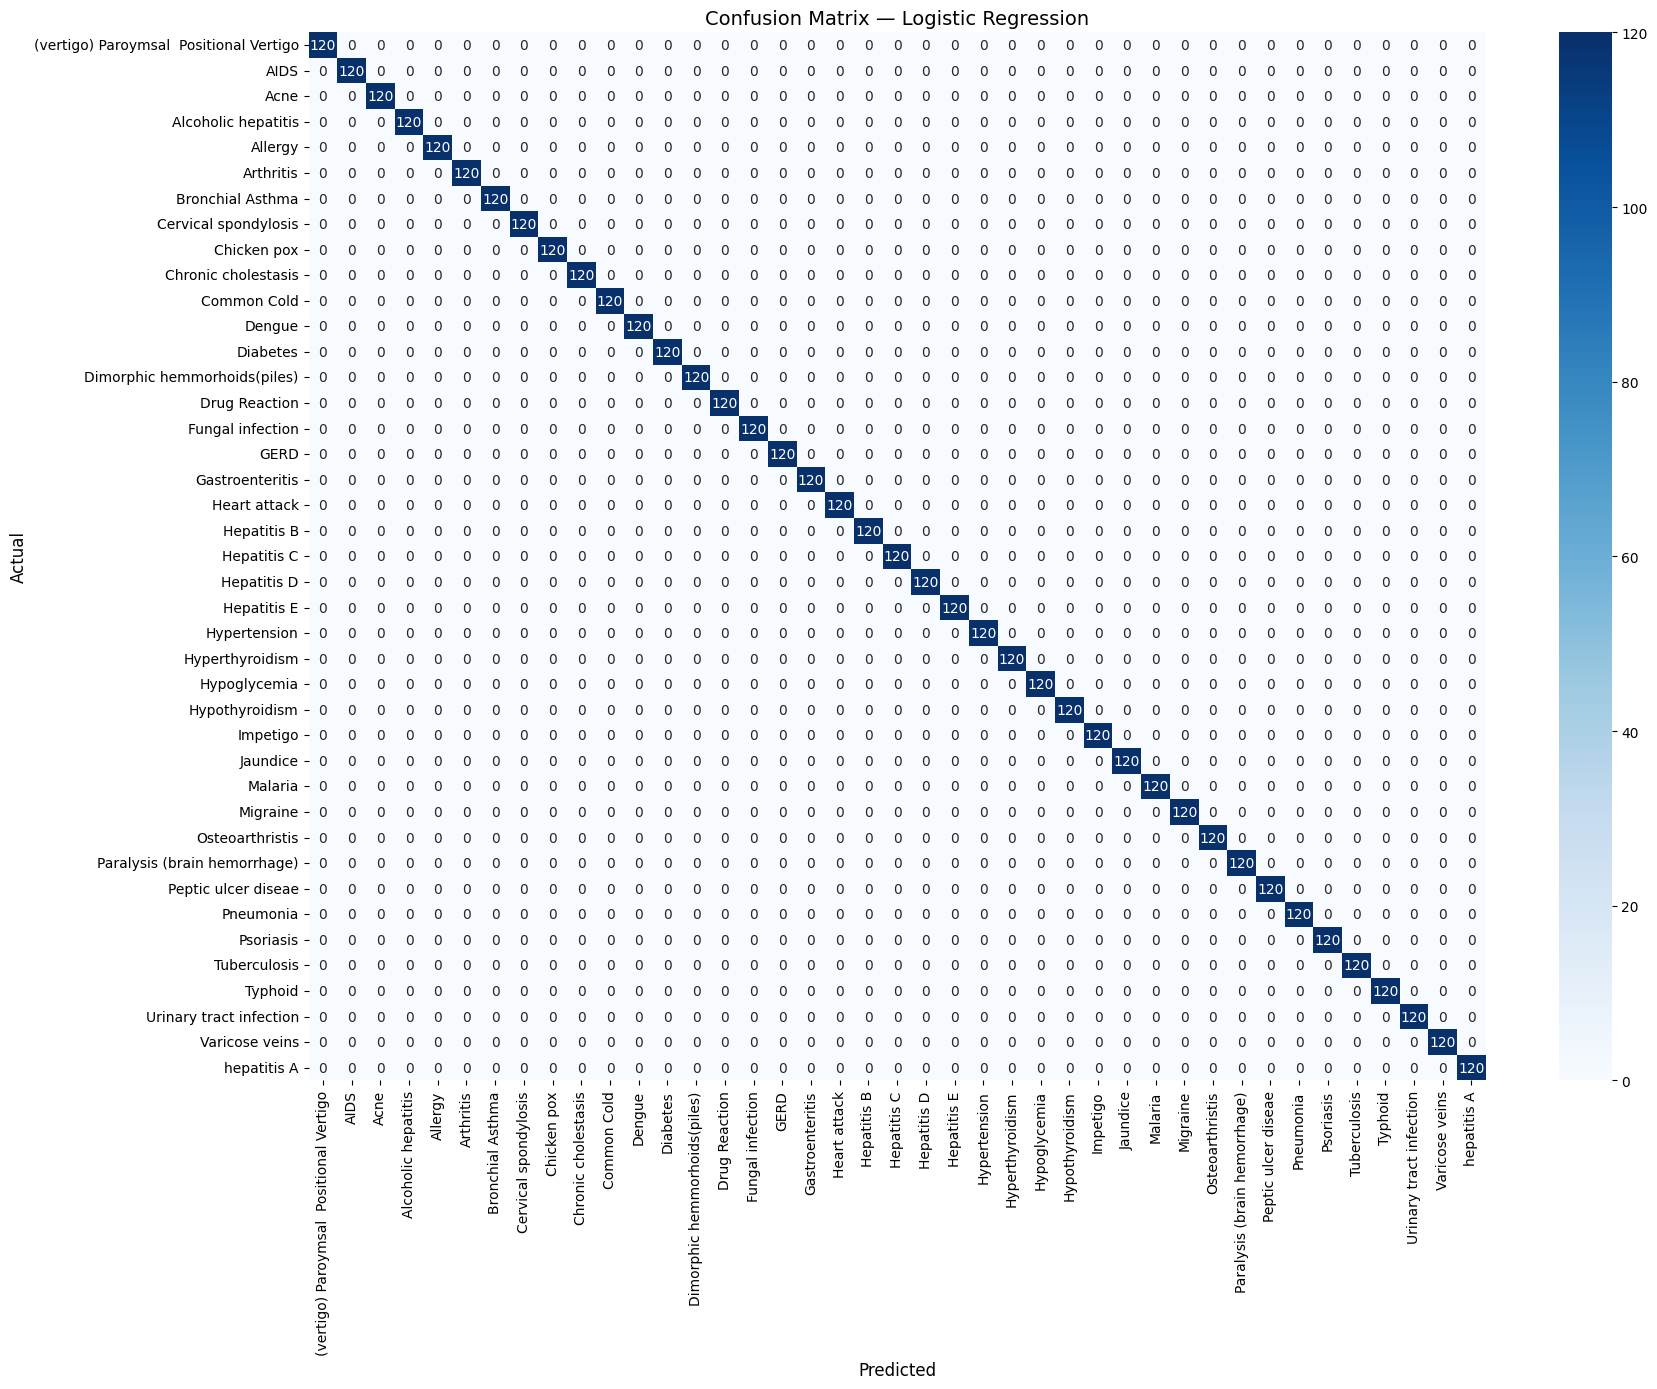

✅ Saved: confusion_matrix.png


In [11]:
# ── Shell 7: Full Evaluation ──────────────────────────────────────────────────
final_preds      = FINAL_MODEL.predict(X_test)
final_proba      = FINAL_MODEL.predict_proba(X_test)
final_acc        = accuracy_score(y_test, final_preds)
top3_acc         = top_k_accuracy_score(y_test, final_proba, k=3)

print(f"\n{'='*60}")
print(f"  FINAL MODEL  : {FINAL_NAME}")
print(f"  Test Accuracy: {final_acc:.4f}")
print(f"  Top-3 Acc    : {top3_acc:.4f}")
print(f"{'='*60}\n")
print(classification_report(y_test, final_preds,
                             target_names=le.classes_, zero_division=0))

# Confusion matrix heatmap
cm = confusion_matrix(y_test, final_preds)
fig, ax = plt.subplots(figsize=(18, 14))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("Actual", fontsize=12)
ax.set_title(f"Confusion Matrix — {FINAL_NAME}", fontsize=14)
plt.xticks(rotation=90); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=120)
plt.show()
print("✅ Saved: confusion_matrix.png")

In [12]:
# ── Shell 8: Top-3 Disease Prediction Function (Chatbot-ready) ────────────────
def predict_top3(symptom_list, model=FINAL_MODEL, label_encoder=le,
                 all_feature_names=list(X_train.columns)):
    """
    Input : list of symptom strings, e.g. ['cough', 'fever', 'headache']
    Output: list of dicts → [{'disease': ..., 'confidence': ...}, ...]
    """
    # Build binary input vector
    input_vec = pd.DataFrame([{col: 0 for col in all_feature_names}])
    for sym in symptom_list:
        sym_clean = sym.strip().lower().replace(' ', '_')
        if sym_clean in input_vec.columns:
            input_vec[sym_clean] = 1

    # Recompute engineered features on the live input
    # (manual, fast version of add_features for a single row)
    total = sum(input_vec[c].values[0] for c in input_vec.columns
                if c in all_feature_names and c not in
                ['total_symptoms','resp_score','digest_score','neuro_score',
                 'skin_score','fever_score','joint_score','liver_score',
                 'dominant_system','severity_flag'])
    input_vec['total_symptoms'] = total

    # Get probabilities
    proba    = model.predict_proba(input_vec)[0]
    top3_idx = proba.argsort()[-3:][::-1]

    results = []
    for idx in top3_idx:
        results.append({
            "disease"   : label_encoder.classes_[idx],
            "confidence": round(float(proba[idx]) * 100, 2)
        })
    return results


# ── Demo ──────────────────────────────────────────────────────────────────────
demo_symptoms = ['cough', 'high_fever', 'breathlessness', 'phlegm']
top3 = predict_top3(demo_symptoms)

print(f"Patient symptoms: {demo_symptoms}\n")
print("🔍 Top-3 Predicted Diseases:")
print("-" * 40)
for i, r in enumerate(top3, 1):
    bar = "█" * int(r['confidence'] / 5)
    print(f"  {i}. {r['disease']:<40} {r['confidence']:>6.2f}%  {bar}")

Patient symptoms: ['cough', 'high_fever', 'breathlessness', 'phlegm']

🔍 Top-3 Predicted Diseases:
----------------------------------------
  1. Bronchial Asthma                          84.20%  ████████████████
  2. Pneumonia                                  9.21%  █
  3. GERD                                       1.21%  


✅ Saved:
   disease_prediction_model.pkl
   label_encoder.pkl
   feature_names.pkl

Model type : Logistic Regression
Features   : 142
Diseases   : 41


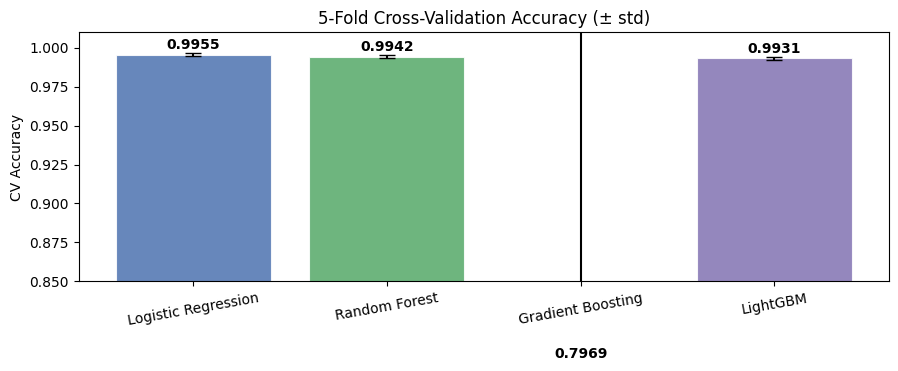

✅ Saved: cv_comparison.png


In [13]:
# ── Shell 9: Save Model & Label Encoder ───────────────────────────────────────
joblib.dump(FINAL_MODEL, "disease_prediction_model.pkl")
joblib.dump(le,          "label_encoder.pkl")
joblib.dump(list(X_train.columns), "feature_names.pkl")

print("✅ Saved:")
print("   disease_prediction_model.pkl")
print("   label_encoder.pkl")
print("   feature_names.pkl")
print(f"\nModel type : {FINAL_NAME}")
print(f"Features   : {X_train.shape[1]}")
print(f"Diseases   : {len(le.classes_)}")

# CV Summary plot
cv_means = {k: v.mean() for k, v in cv_results.items()}
cv_stds  = {k: v.std()  for k, v in cv_results.items()}

fig, ax = plt.subplots(figsize=(9, 4))
names  = list(cv_means.keys())
means  = list(cv_means.values())
stds   = list(cv_stds.values())
colors = ['#4C72B0','#55A868','#C44E52','#8172B2']
bars   = ax.bar(names, means, yerr=stds, color=colors, alpha=0.85,
                capsize=6, edgecolor='white', linewidth=0.8)
ax.set_ylim(0.85, 1.01)
ax.set_ylabel("CV Accuracy")
ax.set_title("5-Fold Cross-Validation Accuracy (± std)")
for bar, m in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f"{m:.4f}", ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.xticks(rotation=10)
plt.tight_layout()
plt.savefig("cv_comparison.png", dpi=120)
plt.show()
print("✅ Saved: cv_comparison.png")